# Install Dependencies

In [30]:
!apt-get install tesseract-ocr -y
!apt-get install poppler-utils -y
!pip install pdf2image pytesseract spacy transformers pandas matplotlib pillow
!python -m spacy download en_core_web_sm

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 43.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# Import Libraries

In [31]:
import pandas as pd
import numpy as np
import re
import pytesseract
import spacy

from pdf2image import convert_from_path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

nlp = spacy.load("en_core_web_sm")

# Upload the PDF

In [32]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# Set the root path directory
pdf_path = "/content/drive/MyDrive/Data Science Challenge/anonymised 1.pdf"

Mounted at /content/drive


# OCR – Extract Text From PDF

In [33]:
# Extract text from pdf
def extract_text_from_pdf(pdf_path):
    images = convert_from_path(pdf_path)
    pages = []

    for i, img in enumerate(images):
        text = pytesseract.image_to_string(img)
        pages.append({
            "page": i + 1,
            "text": text
        })
    return pages

pages = extract_text_from_pdf(pdf_path)
print("Total pages:", len(pages))

Total pages: 4


# Clean OCR Text

In [34]:
def clean_text(text):
    text = text.replace("\n", " ")
    text = re.sub(r"[^a-zA-Z0-9/., ]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

for p in pages:
    p["clean_text"] = clean_text(p["text"])

# Exploratory Data Analysis (EDA)

In [35]:
word_counts = []

for p in pages:
    words = p["clean_text"].split()
    word_counts.append(len(words))

df_wc = pd.DataFrame({
    "page": range(1, len(word_counts)+1),
    "word_count": word_counts
})

df_wc

,page,word_count
0,1,305
1,2,258
2,3,620
3,4,166


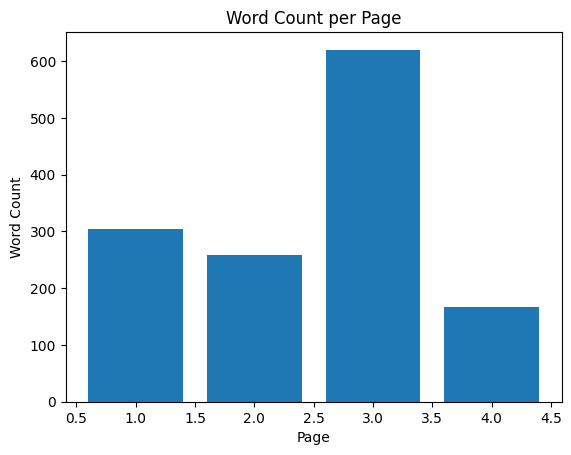

In [36]:
plt.figure()
plt.bar(df_wc["page"], df_wc["word_count"])
plt.xlabel("Page")
plt.ylabel("Word Count")
plt.title("Word Count per Page")
plt.show()

In [37]:
# Most Frequent Words
word_freq = Counter()

for p in pages:
    words = p["clean_text"].lower().split()
    word_freq.update([w for w in words if len(w) > 3])

print("Top 20 words")

for word, count in word_freq.most_common(20):
    print(word, count)

Top 20 words
planning 29
town 20
country 15
notice 12
application 12
permission 11
which 10
development 10
land 8
under 8
granted 8
particulars 7
section 7
date 7
conditions 7
approval 7
part 7
that 7
subject 7
with 7


# Page Classification

In [38]:
def classify_page(text):

    text = text.lower()
    if "decision notice" in text:
        return "Planning Decision Notice"
    if "planning permission" in text:
        return "Planning Permission Approval"
    if "conditional" in text:
        return "Conditional Planning Permission"
    if "land charge" in text:
        return "Land Charge Notice"
    return "Other"

# Extract Application Number

In [39]:
def extract_application_number(text):

    patterns = [

        r"[A-Z]/\d{2,4}/\d{3,5}",
        r"\b\d{2}/\d{4}\b",
        r"\b\d{4}/\d{3,5}\b",
        r"\b[A-Z]/\d{2}/\d{4}\b"
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return match.group()
    return None

# Add Date Extraction Function

In [40]:
def extract_application_date(text):

    patterns = [

        # DD/MM/YYYY
        r"\b\d{1,2}/\d{1,2}/\d{4}\b",

        # DD.MM.YY or DD.MM.YYYY
        r"\b\d{1,2}\.\d{1,2}\.\d{2,4}\b",

        # DD Month YYYY
        r"\b\d{1,2}\s(?:January|February|March|April|May|June|July|August|September|October|November|December)\s\d{4}\b",

        # Month DD YYYY
        r"\b(?:January|February|March|April|May|June|July|August|September|October|November|December)\s\d{1,2}\s\d{4}\b"
    ]

    for pattern in patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            return match.group()
    return None

# Extract Applicant Name

In [41]:
def extract_applicant_name(raw_text):

    # pattern for common title-based names
    pattern = r"\b(Mr|Mrs|Ms|Dr)\.?\s*(?:&\s*(Mr|Mrs)\.?\s*)?[A-Z][A-Za-z.\s]+"
    match = re.search(pattern, raw_text)
    if match:
        return match.group().strip()
    return None

In [42]:
def clean_name(name):

    if name is None:
        return None

    name = name.replace(",", "")
    name = re.sub(r"\s+", " ", name)

    return name.strip()

# Pipeline

In [43]:
results = []

for p in pages:
    text = p["clean_text"]
    page_type = classify_page(text)
    application_number = extract_application_number(text)
    extracted_name = extract_applicant_name(p["text"])
    applicant_name = clean_name(extracted_name)
    application_date = extract_application_date(text)
    results.append({
        "page": p["page"],
        "page_type": page_type,
        "application_number": application_number,
        "applicant_name": applicant_name,
        "application_date": application_date
    })

df_results = pd.DataFrame(results)
df_results

,page,page_type,application_number,applicant_name,application_date
0,1,Conditional Planning Permission,80/1609,Mr. & Mrs.J. M Doe dated,02/80/1609
1,2,Planning Permission Approval,P/00/0759,Mr M Dale,17/07/2000
2,3,Planning Permission Approval,None,None,None
3,4,Planning Permission Approval,P/98/0964,Mrs AM Stephens,13/07/1998


# Save Results

In [44]:
df_results.to_csv("results.csv", index=False)